In [275]:
import pandas as pd
import pandas as pd
import numpy as np 

import seaborn as sns 
import matplotlib.pylab as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from scipy.stats import norm
from scipy import stats

all_wines_original = pd.read_csv("eda.csv")
red_wine_original = pd.read_csv("red_wine_ml.csv")
white_wine_original = pd.read_csv("white_wine_ml.csv")
all_wines_original

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,quality_label,wine_type,alcohol_g_per_L,acidity_to_alcohol_ratio,SO2_ratio,alc_acid_ratio
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,low,red,74.166,0.099776,32.352941,127.027027
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,low,red,77.322,0.100877,37.313433,125.641026
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,low,red,77.322,0.100877,27.777778,125.641026
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,medium,red,77.322,0.144849,28.333333,87.500000
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,low,red,74.166,0.099776,32.352941,127.027027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,medium,white,88.368,0.070161,26.086957,180.645161
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,low,white,75.744,0.087136,33.928571,145.454545
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,medium,white,74.166,0.087641,27.027027,144.615385
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,medium,white,100.992,0.054460,18.181818,232.727273


In [276]:
all_wines_original = all_wines_original.drop_duplicates()
all_wines_original.drop("quality", axis =1, inplace=True)
all_wines_original

D:\Users\Olunia\AppData\Local\Temp\ipykernel_5592\3441289596.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_wines_original.drop("quality", axis =1, inplace=True)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality_label,wine_type,alcohol_g_per_L,acidity_to_alcohol_ratio,SO2_ratio,alc_acid_ratio
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,low,red,74.166,0.099776,32.352941,127.027027
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,low,red,77.322,0.100877,37.313433,125.641026
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,low,red,77.322,0.100877,27.777778,125.641026
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,medium,red,77.322,0.144849,28.333333,87.500000
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,low,red,74.166,0.099776,32.500000,127.027027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,medium,white,88.368,0.070161,26.086957,180.645161
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,low,white,75.744,0.087136,33.928571,145.454545
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,medium,white,74.166,0.087641,27.027027,144.615385
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,medium,white,100.992,0.054460,18.181818,232.727273


### Label Encoder - Wine type

In [277]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

le = LabelEncoder()
all_wines_original['wine_type'] = le.fit_transform(all_wines_original['wine_type'])

all_wines_original['wine_type'].head()

D:\Users\Olunia\AppData\Local\Temp\ipykernel_5592\864379471.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_wines_original['wine_type'] = le.fit_transform(all_wines_original['wine_type'])


0    0
1    0
2    0
3    0
5    0
Name: wine_type, dtype: int32

### Ordinal Encoder - Quality Label

In [278]:
print(all_wines_original['quality_label'].dtype)
print(all_wines_original['quality_label'].unique())


object
['low' 'medium' 'high']


In [279]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[["low", "medium", "high"]], dtype=int) # this is how you can define the label order
all_wines_original['quality_label'] = oe.fit_transform(all_wines_original[['quality_label']])
all_wines_original['quality_label'].head()



D:\Users\Olunia\AppData\Local\Temp\ipykernel_5592\3182098399.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_wines_original['quality_label'] = oe.fit_transform(all_wines_original[['quality_label']])


0    0
1    0
2    0
3    1
5    0
Name: quality_label, dtype: int32

### Split the data - wine type

In [280]:
from sklearn.model_selection import train_test_split

X = all_wines_original.drop('wine_type', axis =1) 
y = all_wines_original['wine_type'] # --> what you're trying to predict

print("original:", all_wines_original.shape, "\nX:", X.shape, "\ny:", y.shape)

original: (5320, 17) 
X: (5320, 16) 
y: (5320,)


### Define the split

In [281]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=420)
print(X_train, X_test)

      fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
917             6.8              0.41         0.31            8.80      0.084   
1725            7.4              0.39         0.23            7.00      0.033   
2377            6.9              0.22         0.37           15.00      0.053   
5635            7.3              0.33         0.22            1.40      0.041   
1550            7.1              0.68         0.00            2.30      0.087   
...             ...               ...          ...             ...        ...   
5992            6.4              0.18         0.28           17.05      0.047   
5706            6.8              0.30         0.26           20.30      0.037   
5454            5.9              0.18         0.29            4.60      0.032   
6351            5.1              0.25         0.36            1.30      0.035   
3546            5.7              0.45         0.42            1.10      0.051   

      free_sulfur_dioxide  

### Feature Scaling

In [282]:
# data normalisation with sklearn
from sklearn.preprocessing import MinMaxScaler

# fit scaler on training data
norm = MinMaxScaler().fit(X_train)

# transform training data
X_train_norm = norm.transform(X_train)

# transform testing data
X_test_norm = norm.transform(X_test)

### Building a model

#### Logistic Regression

In [283]:
from sklearn.linear_model import LogisticRegression

LR_model = LogisticRegression(max_iter=1000) 

In [284]:
LR_model.fit(X_train_norm, y_train)

LogisticRegression(max_iter=1000)

In [285]:
preds = LR_model.predict(X_test_norm)
preds

array([1, 1, 0, ..., 1, 0, 1])

In [286]:
y_test

4882    1
1981    1
636     0
5052    1
4555    1
       ..
3954    1
1443    0
1081    0
401     0
2284    1
Name: wine_type, Length: 1064, dtype: int32

In [287]:
from sklearn.metrics import accuracy_score 

acc = accuracy_score(y_test, preds)
acc

0.9859022556390977

### Random Forest

In [288]:
from sklearn.ensemble import RandomForestClassifier

In [289]:
RF_clf = RandomForestClassifier(random_state=420)

In [290]:
RF_clf.fit(X_train_norm, y_train)

RandomForestClassifier(random_state=420)

In [291]:
preds = RF_clf.predict(X_test_norm)
preds

array([1, 1, 0, ..., 0, 0, 1])

In [292]:
acc = accuracy_score(y_test, preds)
acc

0.9962406015037594

### Split the data Quality Label

In [293]:
from sklearn.model_selection import train_test_split

X = all_wines_original.drop('quality_label', axis =1) 
y = all_wines_original['quality_label'] # --> what you're trying to predict

print("original:", all_wines_original.shape, "\nX:", X.shape, "\ny:", y.shape)

original: (5320, 17) 
X: (5320, 16) 
y: (5320,)


#### Define the split

In [294]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=420)
print(X_train, X_test)

      fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
917             6.8              0.41         0.31            8.80      0.084   
1725            7.4              0.39         0.23            7.00      0.033   
2377            6.9              0.22         0.37           15.00      0.053   
5635            7.3              0.33         0.22            1.40      0.041   
1550            7.1              0.68         0.00            2.30      0.087   
...             ...               ...          ...             ...        ...   
5992            6.4              0.18         0.28           17.05      0.047   
5706            6.8              0.30         0.26           20.30      0.037   
5454            5.9              0.18         0.29            4.60      0.032   
6351            5.1              0.25         0.36            1.30      0.035   
3546            5.7              0.45         0.42            1.10      0.051   

      free_sulfur_dioxide  

In [295]:
# data normalisation with sklearn
from sklearn.preprocessing import MinMaxScaler

# fit scaler on training data
norm = MinMaxScaler().fit(X_train)

# transform training data
X_train_norm = norm.transform(X_train)

# transform testing data
X_test_norm = norm.transform(X_test)

### Logistic Regression - QL

In [296]:
from sklearn.linear_model import LogisticRegression

LR_model = LogisticRegression(max_iter=1000) 
LR_model.fit(X_train_norm, y_train)
lr_preds = LR_model.predict(X_test_norm)
lr_preds

array([0, 0, 0, ..., 1, 1, 0])

In [297]:
y_test

4882    1
1981    1
636     0
5052    1
4555    1
       ..
3954    1
1443    0
1081    1
401     1
2284    0
Name: quality_label, Length: 1064, dtype: int32

In [298]:
from sklearn.metrics import accuracy_score 

acc = accuracy_score(y_test, lr_preds)
acc

0.7359022556390977

In [299]:
# # Logistic Regression - faster in one go
# from sklearn.linear_model import LogisticRegression
# # define model
# LR_model = LogisticRegression(max_iter=1000)
# # fit model
# LR_model.fit(X_train, y_train)
# # make predictions
# LR_preds = LR_model.predict(X_test)

### Random Forest - QL

In [300]:
from sklearn.ensemble import RandomForestClassifier
RF_clf = RandomForestClassifier(random_state=420)
RF_clf.fit(X_train_norm, y_train)

RandomForestClassifier(random_state=420)

In [301]:
rf_preds = RF_clf.predict(X_test_norm)
rf_preds

array([1, 0, 0, ..., 1, 1, 0])

In [302]:
acc = accuracy_score(y_test, rf_preds)
acc

0.7584586466165414

In [303]:
# # Random Forest - in one go
# from sklearn.ensemble import RandomForestClassifier
# # define model
# RF_clf = RandomForestClassifier(random_state=420)
# # fit model
# RF_clf.fit(X_train, y_train)
# # make predictions
# RF_preds = RF_clf.predict(X_test)

## Evaluation Matrix

#### Confusion Matrix - Logistic Regression

In [304]:
print("Confusion matrix:")
print(confusion_matrix(y_test, lr_preds))

Confusion matrix:
[[245 161   0]
 [ 95 538   0]
 [  0  25   0]]


In [305]:
compare = pd.concat([pd.Series(lr_preds), y_test.reset_index(drop=True)], axis="columns")

def self_cm(row):
    pred, actual = row.items()
    if pred[1] == 1:
        return "TP" if pred[1] == actual[1] else "FP"
    else:
        return "TN" if pred[1] == actual[1] else "FN"

CM_col = compare.apply(self_cm, axis=1)

CM_col.value_counts()

TP    538
TN    245
FP    186
FN     95
Name: count, dtype: int64

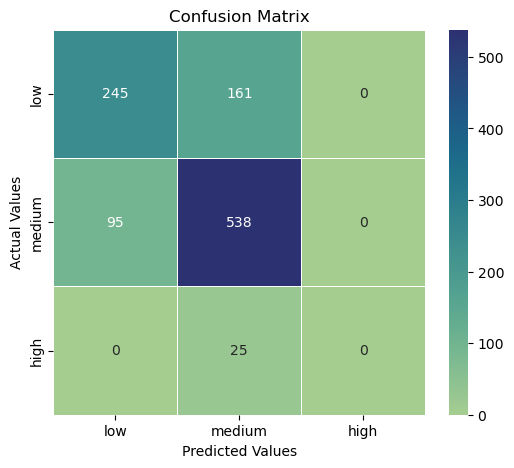

In [306]:
# Compute confusion matrix
cm = confusion_matrix(y_test, lr_preds)

# Convert to DataFrame
cm_df = pd.DataFrame(cm, 
                     index=['low', 'medium', 'high'], 
                     columns=['low', 'medium', 'high'])

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="crest", linewidths=0.5, cbar=True)

# Labels and title
plt.title("Confusion Matrix")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.show()

In [307]:
print("Accuracy score:", accuracy_score(y_test, lr_preds))

Accuracy score: 0.7359022556390977


In [308]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_preds, target_names=["low","medium","high"]))

              precision    recall  f1-score   support

         low       0.72      0.60      0.66       406
      medium       0.74      0.85      0.79       633
        high       0.00      0.00      0.00        25

    accuracy                           0.74      1064
   macro avg       0.49      0.48      0.48      1064
weighted avg       0.72      0.74      0.72      1064



d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [309]:
from sklearn.metrics import cohen_kappa_score
print(cohen_kappa_score(y_test, lr_preds))

0.4419483205291882


### Confusion Matrix - Random Forest

In [310]:
print("Confusion matrix:")
print(confusion_matrix(y_test, rf_preds))

Confusion matrix:
[[261 145   0]
 [ 87 546   0]
 [  0  25   0]]


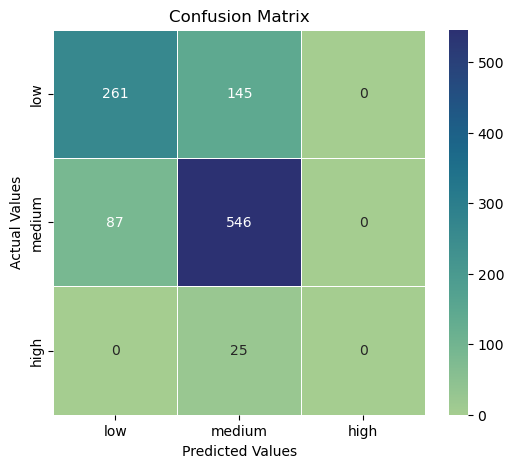

In [311]:
# Compute confusion matrix
cm = confusion_matrix(y_test, rf_preds)

# Convert to DataFrame
cm_df = pd.DataFrame(cm, 
                     index=['low', 'medium', 'high'], 
                     columns=['low', 'medium', 'high'])

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="crest", linewidths=0.5, cbar=True)

# Labels and title
plt.title("Confusion Matrix")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.show()

In [312]:
print("Accuracy score:", accuracy_score(y_test, rf_preds))

Accuracy score: 0.7584586466165414


In [313]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_preds, target_names=["low","medium","high"]))

              precision    recall  f1-score   support

         low       0.72      0.60      0.66       406
      medium       0.74      0.85      0.79       633
        high       0.00      0.00      0.00        25

    accuracy                           0.74      1064
   macro avg       0.49      0.48      0.48      1064
weighted avg       0.72      0.74      0.72      1064



d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [314]:
from sklearn.metrics import cohen_kappa_score
print(cohen_kappa_score(y_test, lr_preds))

0.4419483205291882


### Imbalanced Data - SMOTE

In [315]:
from imblearn.over_sampling import SMOTE

In [316]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import numpy as np

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Apply SMOTE to the training data
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Print before and after class distribution
print("Original class distribution:", np.bincount(y_train))
print("Resampled class distribution:", np.bincount(y_train_resampled))

Original class distribution: [1378 2232  114]
Resampled class distribution: [2232 2232 2232]


In [317]:
# Step 3: Train Machine Learning Model (Random Forest)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_resampled, y_train_resampled)

# Step 4: Predict & Evaluate Model
y_pred = clf.predict(X_test)


# Print Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[435 174   1]
 [213 684  50]
 [  1  29   9]]

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.71      0.69       610
           1       0.77      0.72      0.75       947
           2       0.15      0.23      0.18        39

    accuracy                           0.71      1596
   macro avg       0.53      0.56      0.54      1596
weighted avg       0.72      0.71      0.71      1596



In [ ]:
print("Accuracy score:", accuracy_score(y_test, y_pred))

# Accuracy = (Correct Predictions) / (Total Predictions)

# If the total number of predictions increased significantly, accuracy can decrease, even if the model is making more correct predictions overall.

Accuracy score: 0.706766917293233


In [319]:
from sklearn.metrics import cohen_kappa_score
print(cohen_kappa_score(y_test, y_pred))

0.42938906659067977


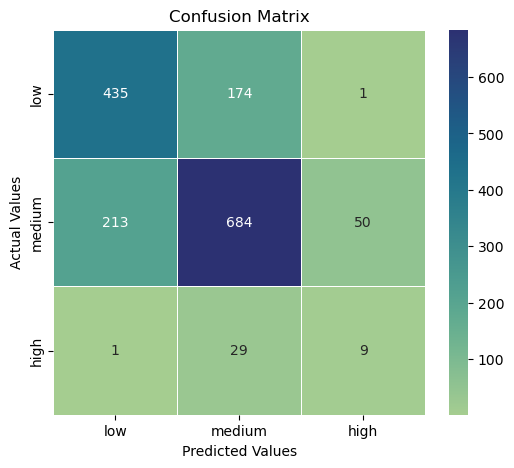

In [227]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert to DataFrame
cm_df = pd.DataFrame(cm, 
                     index=['low', 'medium', 'high'], 
                     columns=['low', 'medium', 'high'])

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="crest", linewidths=0.5, cbar=True)

# Labels and title
plt.title("Confusion Matrix")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.show()

### Gradient Boost ML Model

In [322]:
from sklearn.ensemble import GradientBoostingClassifier

In [323]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and configure the Gradient Boosting model
gb_clf = GradientBoostingClassifier(
    n_estimators=100,   # number of boosting stages to perform
    learning_rate=0.1,  # shrinks the contribution of each tree
    max_depth=3,        # maximum depth of the individual regression estimators
    random_state=42
)

# Train the model on the training data
gb_clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = gb_clf.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7340225563909775

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.64      0.66       390
           1       0.76      0.82      0.79       648
           2       0.00      0.00      0.00        26

    accuracy                           0.73      1064
   macro avg       0.48      0.49      0.48      1064
weighted avg       0.72      0.73      0.72      1064



In [324]:
print(cohen_kappa_score(y_test, y_pred))

0.4413755231677996
